# Assignment 1 — From Color to Structure: A Computer Vision Pipeline

**Student:** Joud Thaher  
**Course:** Computer Vision  
**GitHub Repository:** https://github.com/JHT127/image-to-structure-cv-pipeline 

---

## Overview

In this notebook, I'll build a full image processing pipeline that starts from a regular color image and ends with a structured edge-based representation of it.  
The idea is to go through several stages, each one building on the previous:

```
Color Image → Grayscale → Noise Reduction → Edge Detection → Structured Representation
```

I'll be using **Python**, **OpenCV**, **NumPy**, and **Matplotlib** throughout the notebook.  
Each step includes the code, a visualization, and my explanation of what's happening and why.

---

## Imports and Setup

Before anything, I'll import all the libraries I need and define a few helper functions to keep the code clean and consistent throughout.

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ── Styling ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#F8F8F8',
    'axes.facecolor'   : '#F8F8F8',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlepad'    : 10,
    'font.family'      : 'sans-serif',
})

# ── Output folder ─────────────────────────────────────────────────────────────
os.makedirs('outputs', exist_ok=True)

# ── Helper: save image ────────────────────────────────────────────────────────
def save_output(filename, image):
    path = os.path.join('outputs', filename)
    cv2.imwrite(path, image)
    print(f"  Saved -> {path}")

# ── Helper: show a row of images cleanly ──────────────────────────────────────
def show_images(images, titles, cmaps=None, figsize=(18, 5), suptitle=None):
    n = len(images)
    cmaps = cmaps or [None] * n
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, fontweight='bold', y=1.01)
    for ax, img, title, cmap in zip(axes, images, titles, cmaps):
        ax.imshow(img, cmap=cmap, interpolation='lanczos')
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout(pad=1.5)
    plt.show()

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Step 1 — Load and Display the Color Image

### What am I doing here?

The first step is to load the image and understand what it actually is as data — not just visually, but numerically.

A color image in a computer is stored as a **3D NumPy array**:
- The first two dimensions are the **height** and **width** (the pixel grid).
- The third dimension has **3 values per pixel**, one for each color channel: **Red, Green, Blue**.

So the shape of any color image is: `(height, width, 3)`.

> **Important:** OpenCV loads images in **BGR order** (Blue, Green, Red — not RGB).  
> This matters when displaying with Matplotlib which expects RGB, so we always convert before displaying.

Each pixel value is an integer between **0 and 255** — `0` means none of that color, `255` means full intensity.

### Histogram — What and Why?

A **histogram** plots how many pixels have each intensity value (0–255) for each color channel.  
It's a powerful diagnostic tool — it tells us which colors are **dominant**, how **bright or dark** the image is, and whether colors are **balanced or skewed**.  
In our case, since the house is red, we'd expect a strong peak in the Red channel histogram.

Image Information:
  Shape       : (597, 576, 3)  ->  (height, width, channels)
  Height      : 597 pixels
  Width       : 576 pixels
  Channels    : 3  (Red, Green, Blue)
  Data type   : uint8  ->  values from 0 to 255
  Total pixels: 343,872


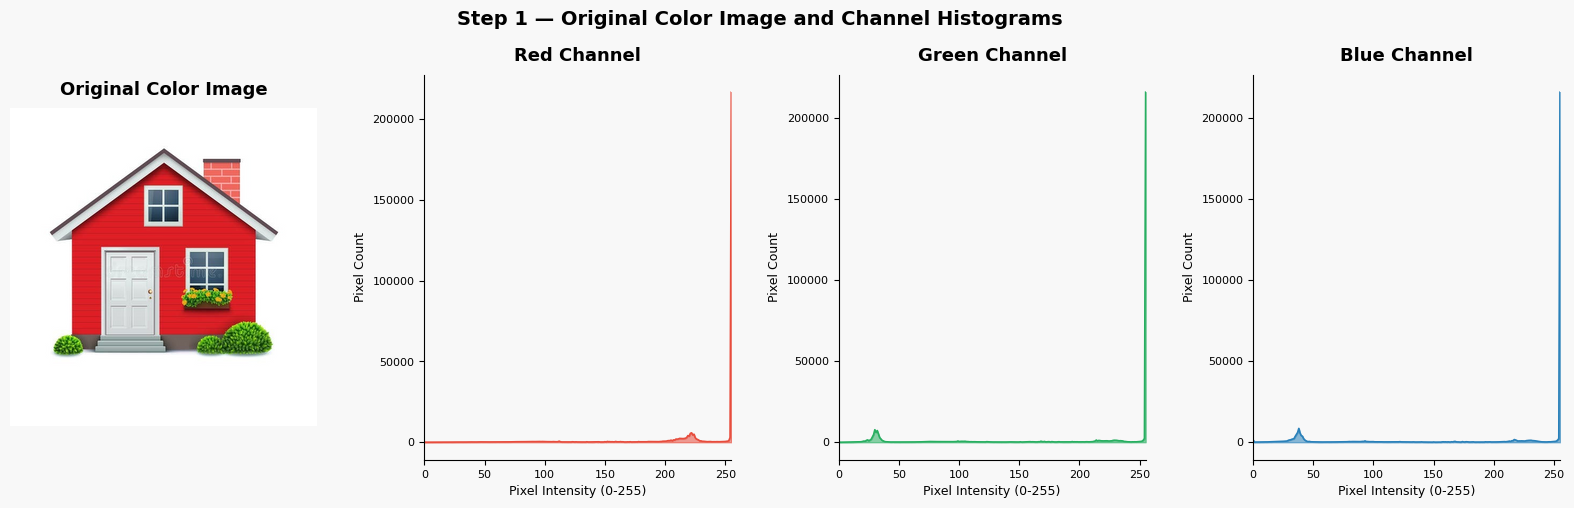

In [11]:
# ── Load ──────────────────────────────────────────────────────────────────────
img_bgr = cv2.imread('data/img.jpg')
if img_bgr is None:
    raise FileNotFoundError("Image not found! Make sure 'data/img.jpg' exists.")

# Convert BGR -> RGB for correct display in Matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print("Image Information:")
print(f"  Shape       : {img_rgb.shape}  ->  (height, width, channels)")
print(f"  Height      : {img_rgb.shape[0]} pixels")
print(f"  Width       : {img_rgb.shape[1]} pixels")
print(f"  Channels    : {img_rgb.shape[2]}  (Red, Green, Blue)")
print(f"  Data type   : {img_rgb.dtype}  ->  values from 0 to 255")
print(f"  Total pixels: {img_rgb.shape[0] * img_rgb.shape[1]:,}")

# ── Display image + per-channel histograms ────────────────────────────────────
fig = plt.figure(figsize=(20, 5))
fig.suptitle('Step 1 — Original Color Image and Channel Histograms',
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# Image panel
ax_img = fig.add_subplot(gs[0, 0])
ax_img.imshow(img_rgb, interpolation='lanczos')
ax_img.set_title('Original Color Image')
ax_img.axis('off')

# One histogram per channel
channel_info = [
    (0, 'Red Channel',   '#E74C3C'),
    (1, 'Green Channel', '#27AE60'),
    (2, 'Blue Channel',  '#2980B9'),
]
for col_idx, (ch, label, color) in enumerate(channel_info):
    ax = fig.add_subplot(gs[0, col_idx + 1])
    hist = cv2.calcHist([img_rgb], [ch], None, [256], [0, 256]).flatten()
    ax.fill_between(range(256), hist, color=color, alpha=0.55)
    ax.plot(hist, color=color, linewidth=1.2)
    ax.set_title(label)
    ax.set_xlabel('Pixel Intensity (0-255)', fontsize=9)
    ax.set_ylabel('Pixel Count', fontsize=9)
    ax.set_xlim([0, 255])
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.subplots_adjust(top=0.88, wspace=0.35)
plt.show()

### What do I observe?

The image shape is `(H, W, 3)`. The `3` at the end represents the three color channels: Red, Green, Blue. Together they produce every color we see.

Looking at the histograms:
- The **Red channel** shows a strong peak at high intensities — expected, since the house is predominantly red.
- The **Green channel** has moderate activity — coming from the bushes, flowers, and blended colors.
- The **Blue channel** is mostly low — blue is barely present in this image.

The histogram doesn't just confirm what we see visually — it proves it numerically. That's what makes it such a useful tool.

---

## Step 2 — Convert to Grayscale

### What am I doing here?

Now I'll convert the color image into a **grayscale** image — collapsing the 3 color channels into a **single channel** representing only **brightness**.

The conversion uses a weighted formula based on human color perception:

$$\text{Gray} = 0.299 \times R + 0.587 \times G + 0.114 \times B$$

Green gets the highest weight because our eyes are most sensitive to it. This isn't a simple average — it's designed to match how we perceive brightness.

After this step, the shape changes: `(H, W, 3)` becomes `(H, W)` — no third dimension anymore.

**What's preserved:** Structure, shapes, edges, contrast.  
**What's lost:** All color information.

### Histogram — Before vs After

Comparing the color histogram (3 separate curves) to the grayscale histogram (1 curve) shows exactly what happened:  
all that color variety got collapsed into a single brightness scale.

Grayscale Image Information:
  Shape      : (597, 576)  ->  (height, width) — no channels dimension
  Data type  : uint8
  Pixel range: 8 - 255
  Note: starts at 8 not 0 — this image simply has no pure-black pixels
  Saved -> outputs\step1_grayscale.jpg


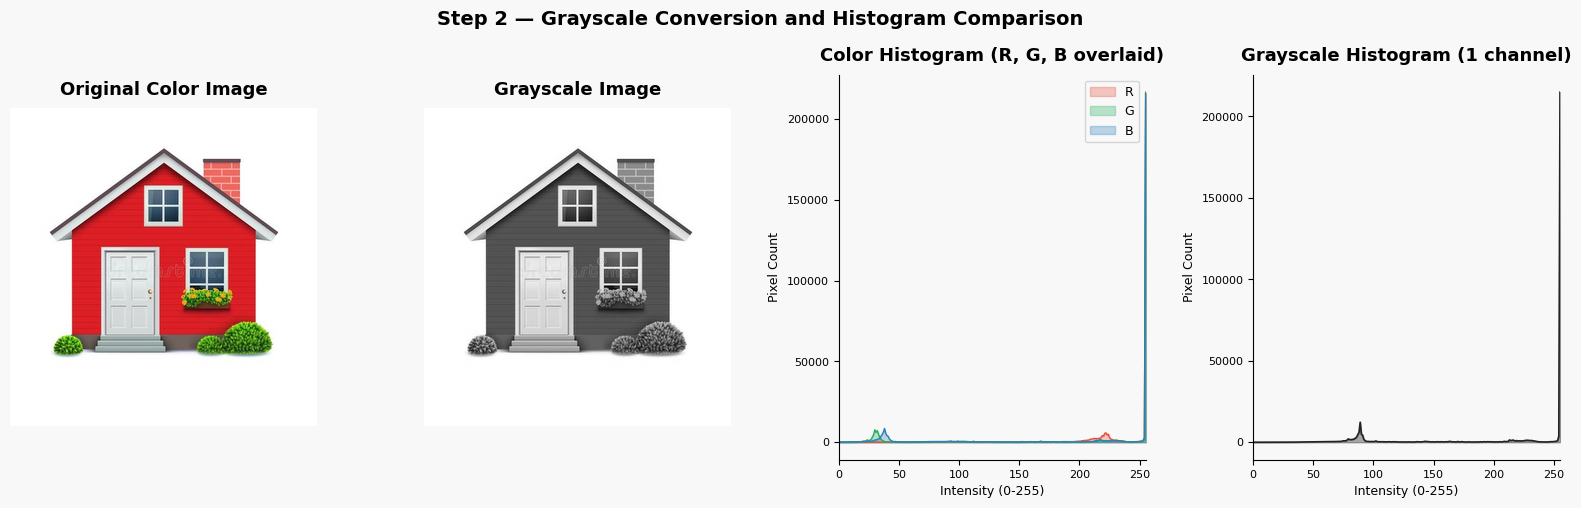

In [12]:
# ── Convert to grayscale ──────────────────────────────────────────────────────
# Using img_bgr (the original) — img_rgb was made only for display, not processing
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Grayscale Image Information:")
print(f"  Shape      : {img_gray.shape}  ->  (height, width) — no channels dimension")
print(f"  Data type  : {img_gray.dtype}")
print(f"  Pixel range: {img_gray.min()} - {img_gray.max()}")
print(f"  Note: starts at {img_gray.min()} not 0 — this image simply has no pure-black pixels")

save_output('step1_grayscale.jpg', img_gray)

# ── Display: original | grayscale | color histogram | grayscale histogram ──────
fig = plt.figure(figsize=(20, 5))
fig.suptitle('Step 2 — Grayscale Conversion and Histogram Comparison',
             fontsize=14, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

# Original
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img_rgb, interpolation='lanczos')
ax1.set_title('Original Color Image')
ax1.axis('off')

# Grayscale
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(img_gray, cmap='gray', interpolation='lanczos')
ax2.set_title('Grayscale Image')
ax2.axis('off')

# Color histograms overlaid
ax3 = fig.add_subplot(gs[0, 2])
for label, color, ch in [('R','#E74C3C',0), ('G','#27AE60',1), ('B','#2980B9',2)]:
    h = cv2.calcHist([img_rgb], [ch], None, [256], [0, 256]).flatten()
    ax3.fill_between(range(256), h, color=color, alpha=0.3, label=label)
    ax3.plot(h, color=color, linewidth=1)
ax3.set_title('Color Histogram (R, G, B overlaid)')
ax3.set_xlabel('Intensity (0-255)', fontsize=9)
ax3.set_ylabel('Pixel Count', fontsize=9)
ax3.set_xlim([0, 255])
ax3.legend(fontsize=9)
ax3.tick_params(labelsize=8)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# Grayscale histogram
ax4 = fig.add_subplot(gs[0, 3])
h_gray = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
ax4.fill_between(range(256), h_gray, color='#555555', alpha=0.5)
ax4.plot(h_gray, color='#222222', linewidth=1.2)
ax4.set_title('Grayscale Histogram (1 channel)')
ax4.set_xlabel('Intensity (0-255)', fontsize=9)
ax4.set_ylabel('Pixel Count', fontsize=9)
ax4.set_xlim([0, 255])
ax4.tick_params(labelsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

fig.subplots_adjust(top=0.88, wspace=0.35)
plt.show()

### What do I observe?

The image is now in shades of gray — all color is gone, but the shapes and structure are completely intact.

Looking at the histograms, the change is very clear:
- **Before:** 3 separate colored curves, each telling a different story about R, G, B.
- **After:** One single gray curve — all channel information merged into one brightness distribution.

The peak near the high end (200–255) in the grayscale histogram comes from the bright white background and light-colored door. The darker tones (lower end) come from the roof and shadows.

The minimum value is **8, not 0** — this just means there are no perfectly black pixels in this image. Completely normal.

---

## Step 3 — Noise Reduction (Gaussian Smoothing)

### What am I doing here?

Before detecting edges, we need to **reduce noise** in the image.

**What is noise?**  
Real images always have small random variations in pixel brightness — tiny imperfections from the camera sensor, lighting, or compression. This shows up as a fine grain.

**Why does this matter for edge detection?**  
Edge detection finds places where brightness changes **sharply**. But noise also creates small sharp changes. Without smoothing, the edge detector picks up all that noise as fake edges — making the result very messy.

**How does Gaussian smoothing work?**  
It replaces each pixel with a **weighted average of its neighbors** — closer neighbors get more weight. This slightly blurs the image but removes high-frequency noise while keeping major features like real edges intact.

The `kernel_size` controls how much blur is applied — I'll compare two values.

  Saved -> outputs\step2_smoothed.jpg


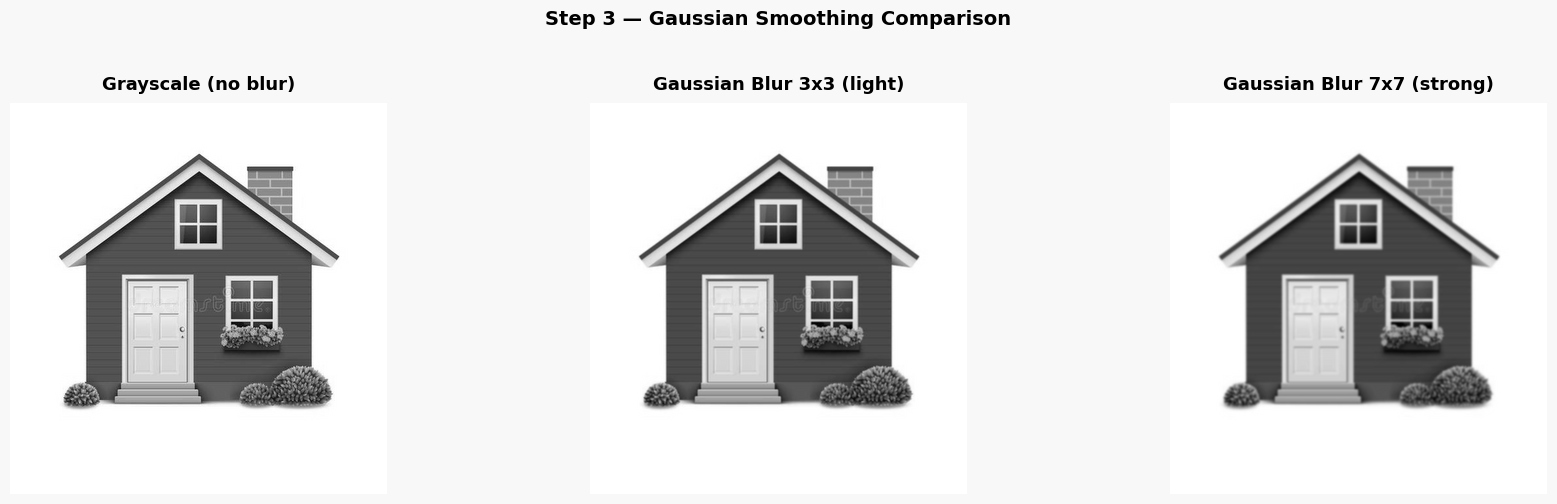

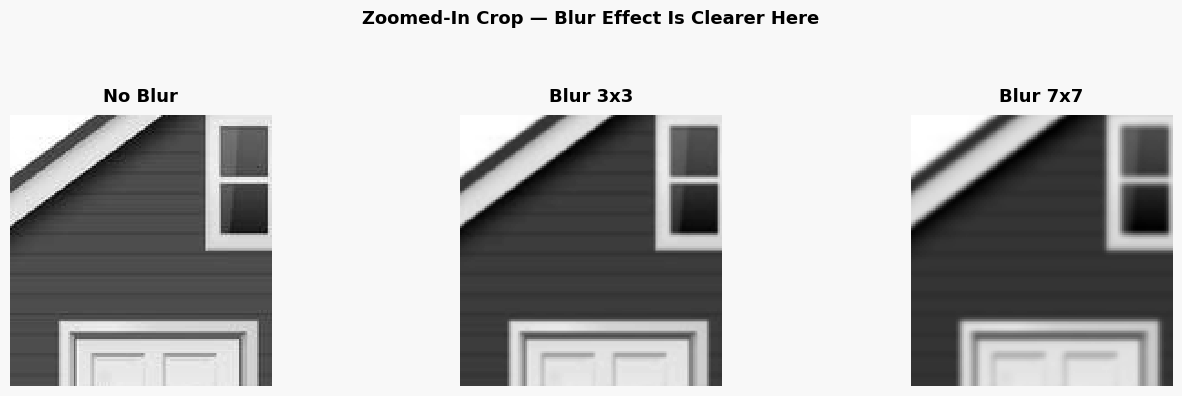

In [13]:
# ── Apply Gaussian blur ───────────────────────────────────────────────────────
# Kernel size must be odd numbers (3, 5, 7 ...)
# sigmaX=0 tells OpenCV to calculate sigma automatically from the kernel size
img_blur_mild   = cv2.GaussianBlur(img_gray, (3, 3), sigmaX=0)  # light smoothing
img_blur_strong = cv2.GaussianBlur(img_gray, (7, 7), sigmaX=0)  # stronger smoothing

# We'll use mild blur going forward
img_blur = img_blur_mild

save_output('step2_smoothed.jpg', img_blur)

# ── Full-size comparison ──────────────────────────────────────────────────────
show_images(
    [img_gray, img_blur_mild, img_blur_strong],
    ['Grayscale (no blur)', 'Gaussian Blur 3x3 (light)', 'Gaussian Blur 7x7 (strong)'],
    cmaps=['gray', 'gray', 'gray'],
    figsize=(18, 5),
    suptitle='Step 3 — Gaussian Smoothing Comparison'
)

# ── Zoomed crop to make the difference visible ────────────────────────────────
H, W = img_gray.shape
crop = (slice(H//4, H//2), slice(W//4, W//2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Zoomed-In Crop — Blur Effect Is Clearer Here',
             fontsize=13, fontweight='bold', y=1.01)

for ax, img, title in zip(axes,
    [img_gray[crop], img_blur_mild[crop], img_blur_strong[crop]],
    ['No Blur', 'Blur 3x3', 'Blur 7x7']):
    ax.imshow(img, cmap='gray', interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout(pad=2)
plt.show()

### What do I observe?

- With a `3x3` kernel: the blur is very subtle at full scale. In the zoomed crop, you can see the edges are slightly softened — enough to smooth pixel-level noise without losing real structure.
- With a `7x7` kernel: the image becomes visibly softer and fine details start to fade.

I'll use the `3x3` blur going forward. It's the right balance between noise removal and edge preservation.

---

## Step 4 — Edge Detection

### What am I doing here?

Edge detection finds the **boundaries** in the image — places where pixel brightness changes sharply from one area to another. Mathematically, we're looking for the **gradient** of the image: how fast and in what direction the brightness changes.

I'll apply **two different methods** and compare their results.

---

### Method A — Sobel Edge Detection

Sobel applies two small filters to measure the rate of brightness change:
- **Sobel X** — detects vertical edges (horizontal brightness change)
- **Sobel Y** — detects horizontal edges (vertical brightness change)

We combine them to get the overall edge strength:
$$\text{Magnitude} = \sqrt{G_x^2 + G_y^2}$$

The result is a **gradient map** — brighter areas mean stronger edges. It's continuous, not binary.

  Saved -> outputs\step3a_sobel_edges.jpg


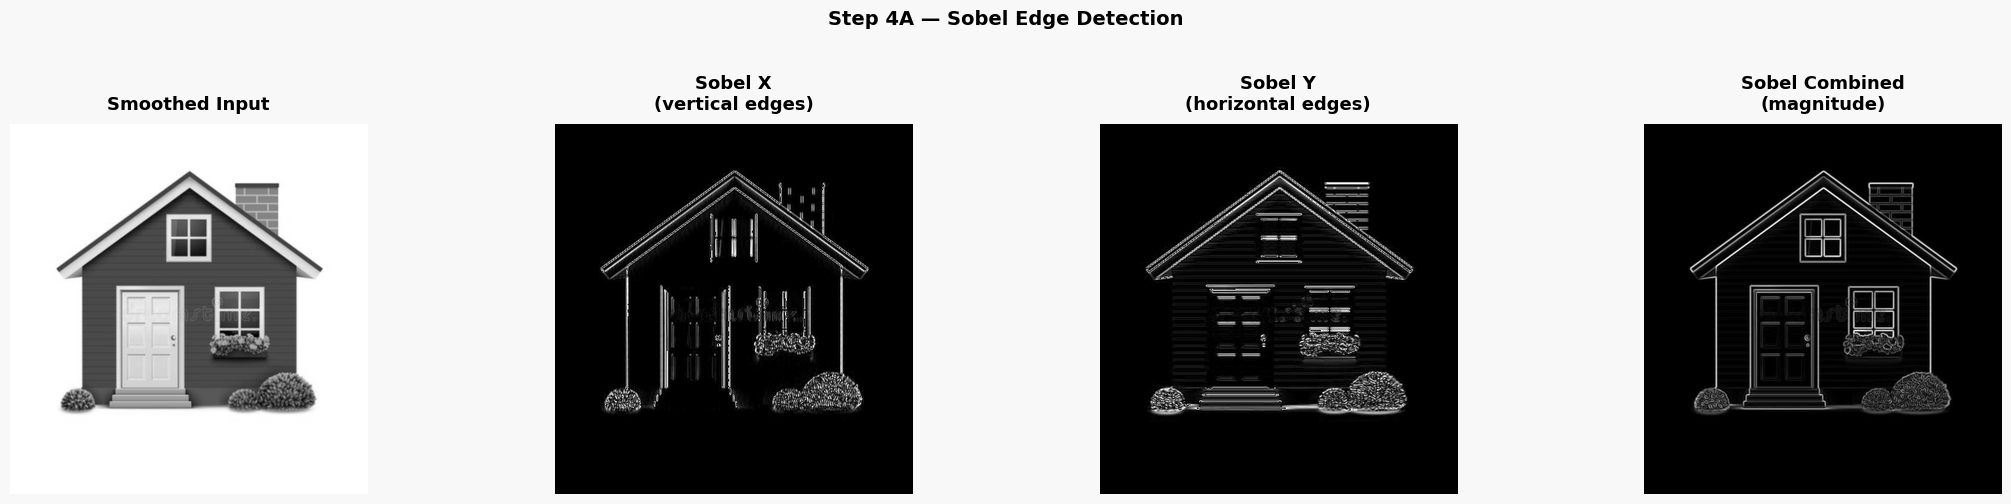

In [14]:
# ── Sobel ─────────────────────────────────────────────────────────────────────
# CV_64F = 64-bit float so negative gradient values are not clipped to 0
sobel_x = cv2.Sobel(img_blur, cv2.CV_64F, dx=1, dy=0, ksize=3)
sobel_y = cv2.Sobel(img_blur, cv2.CV_64F, dx=0, dy=1, ksize=3)

# Combine: magnitude = sqrt(Gx^2 + Gy^2)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

# Normalize to 0-255 for display and saving
sobel_norm = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

save_output('step3a_sobel_edges.jpg', sobel_norm)

show_images(
    [img_blur,
     np.abs(sobel_x).astype(np.uint8),
     np.abs(sobel_y).astype(np.uint8),
     sobel_norm],
    ['Smoothed Input',
     'Sobel X\n(vertical edges)',
     'Sobel Y\n(horizontal edges)',
     'Sobel Combined\n(magnitude)'],
    cmaps=['gray', 'gray', 'gray', 'gray'],
    figsize=(22, 5),
    suptitle='Step 4A — Sobel Edge Detection'
)

#### Sobel — What do I observe?

- **Sobel X** highlights edges running vertically (left-to-right brightness changes)
- **Sobel Y** highlights edges running horizontally (top-to-bottom brightness changes)
- **Combined:** All edges in all directions

The result is **thick and gradient-like** — it's measuring the *strength* of the change, not producing a clean binary line. Think of it as a heat map of "how much edge is here".

---

### Method B — Canny Edge Detection

Canny is a smarter multi-step algorithm:
1. **Gradient calculation** (like Sobel)
2. **Non-maximum suppression** — thins edges to single-pixel-wide lines
3. **Double thresholding** — filters edges by strength using two thresholds
4. **Hysteresis** — keeps weak edges only if connected to strong ones

The two thresholds:
- Below `threshold1` → discarded
- Above `threshold2` → definitely an edge
- Between both → kept only if connected to a strong edge

  Saved -> outputs\step3b_canny_edges.jpg


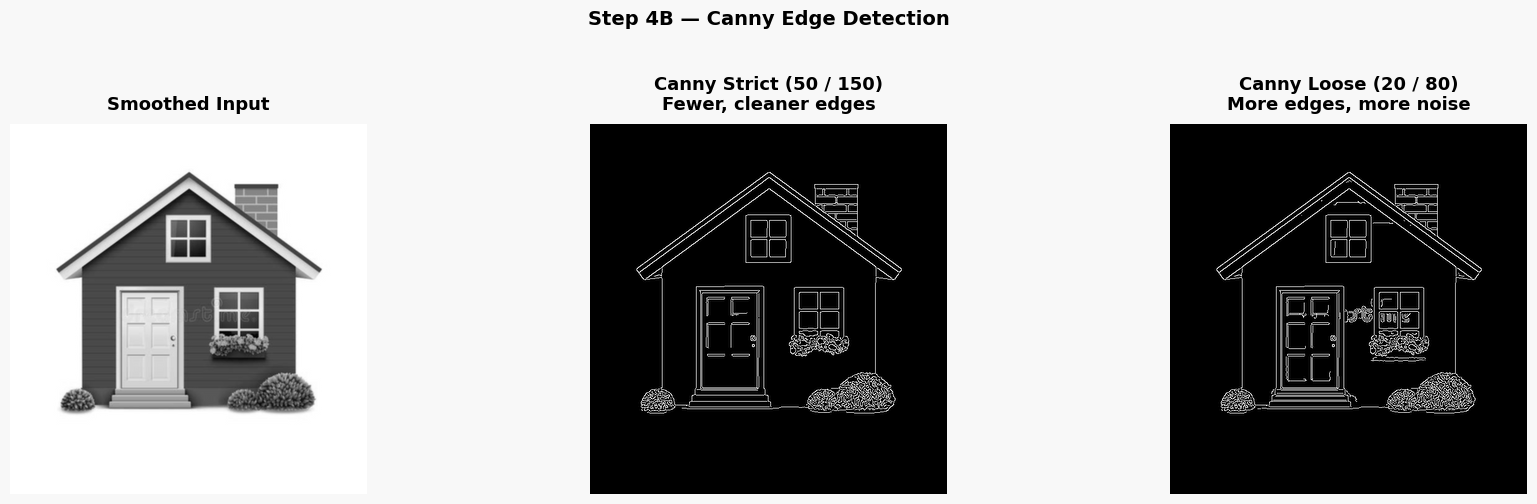

In [15]:
# ── Canny ─────────────────────────────────────────────────────────────────────
canny_strict = cv2.Canny(img_blur, threshold1=50, threshold2=150)  # cleaner
canny_loose  = cv2.Canny(img_blur, threshold1=20, threshold2=80)   # more detail

save_output('step3b_canny_edges.jpg', canny_strict)

show_images(
    [img_blur, canny_strict, canny_loose],
    ['Smoothed Input',
     'Canny Strict (50 / 150)\nFewer, cleaner edges',
     'Canny Loose (20 / 80)\nMore edges, more noise'],
    cmaps=['gray', 'gray', 'gray'],
    figsize=(18, 5),
    suptitle='Step 4B — Canny Edge Detection'
)

#### Canny — What do I observe?

- Canny produces **thin, single-pixel-wide lines** — a much more precise result than Sobel.
- Strict thresholds (50/150): only the strongest, most confident edges are kept — clean result.
- Loose thresholds (20/80): more edges appear including fine texture, but also more noise remnants.

---

### Sobel vs Canny — Direct Comparison

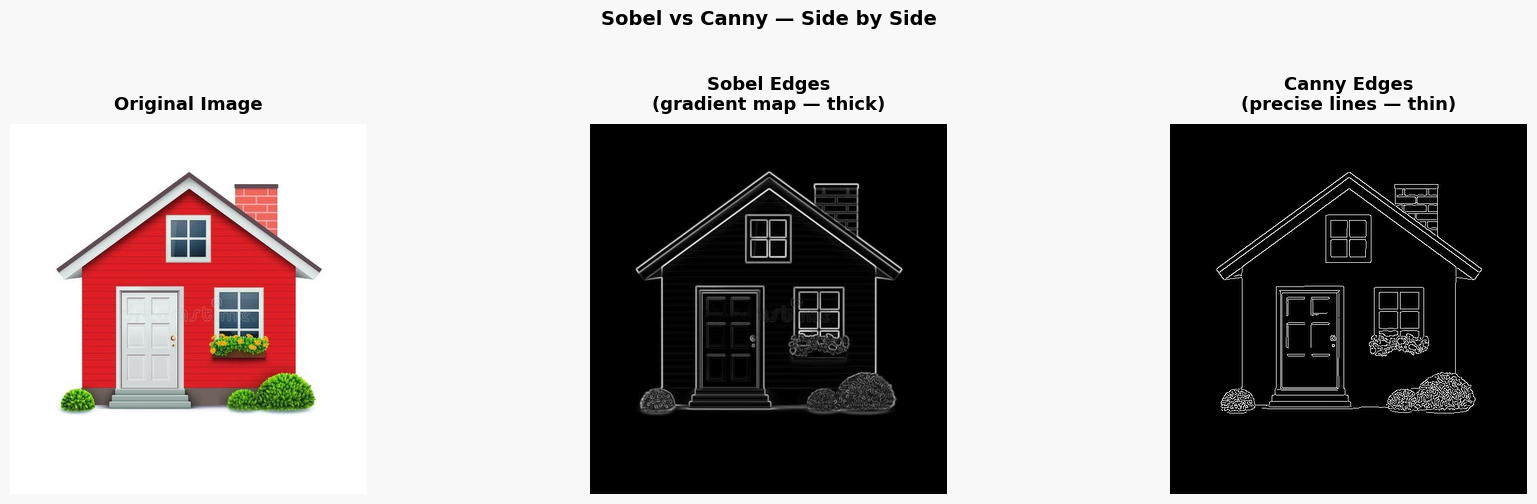

In [16]:
show_images(
    [img_rgb, sobel_norm, canny_strict],
    ['Original Image',
     'Sobel Edges\n(gradient map — thick)',
     'Canny Edges\n(precise lines — thin)'],
    cmaps=[None, 'gray', 'gray'],
    figsize=(18, 5),
    suptitle='Sobel vs Canny — Side by Side'
)

#### Comparison Summary

| Feature | Sobel | Canny |
|---|---|---|
| Edge thickness | Thick / gradient-like | Thin / single-pixel |
| Output type | Continuous (0-255) | Binary (0 or 255) |
| Noise sensitivity | Higher | Lower (hysteresis filters weak noise) |
| Control | Kernel size only | Two thresholds |
| Best for | Gradient maps, weighting | Precise boundary detection |

**Conclusion:** Canny gives cleaner, more precise results. I'll use it in the final step.

---

## Step 5 — From Edges to Structure

### What am I doing here?

Now that we have a clean edge map, we can treat it as a **structural representation** of the original image.  
The edges are where the meaningful information lives — the outlines of objects, the boundaries between regions, the geometry of the scene.

To make this concrete, I'll:
1. **Find the major contours** from the Canny edge map using `cv2.findContours`
2. **Draw them on a clean black canvas** to visualize pure structure
3. **Overlay them on the original** to confirm they match the real boundaries
4. Discuss what information is **present vs. lost**

`cv2.findContours` traces connected white pixels in the edge map into geometric curves that can be drawn, measured, and analyzed.

  Total contours found    : 70
  Significant (area >= 50) : 16
  Saved -> outputs\step4_edge_map.jpg
  Saved -> outputs\step4_contours.jpg
  Saved -> outputs\step4_overlay.jpg


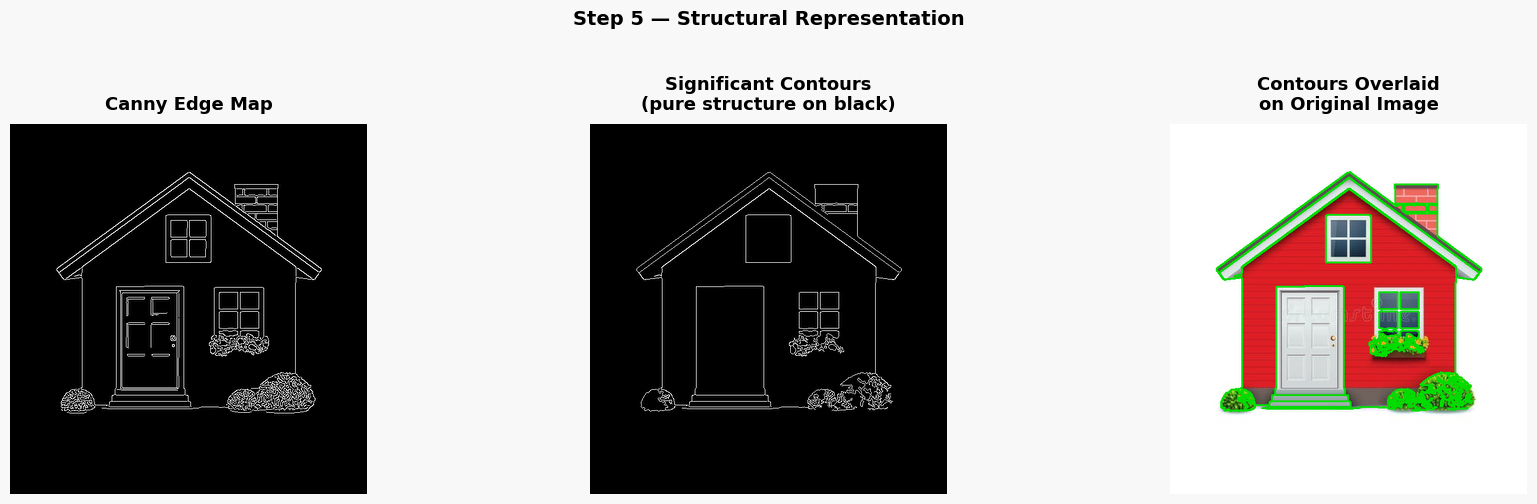

In [17]:
# ── Find contours ─────────────────────────────────────────────────────────────
contours, _ = cv2.findContours(canny_strict, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter out tiny contours that are likely noise dots
MIN_AREA = 50
significant = [c for c in contours if cv2.contourArea(c) >= MIN_AREA]

print(f"  Total contours found    : {len(contours)}")
print(f"  Significant (area >= {MIN_AREA}) : {len(significant)}")

# ── Build visualizations ──────────────────────────────────────────────────────

# Contours on a black canvas (pure structure)
canvas = np.zeros_like(img_gray)
cv2.drawContours(canvas, significant, -1, 255, thickness=1)

# Contours overlaid on the original image in green
overlay_bgr = img_bgr.copy()
cv2.drawContours(overlay_bgr, significant, -1, (0, 220, 0), thickness=2)
overlay_rgb = cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB)

# Save
save_output('step4_edge_map.jpg', canny_strict)
save_output('step4_contours.jpg', canvas)
save_output('step4_overlay.jpg', overlay_bgr)

show_images(
    [canny_strict, canvas, overlay_rgb],
    ['Canny Edge Map',
     'Significant Contours\n(pure structure on black)',
     'Contours Overlaid\non Original Image'],
    cmaps=['gray', 'gray', None],
    figsize=(18, 5),
    suptitle='Step 5 — Structural Representation'
)

### What do I observe? What's missing?

**What the structured representation captures:**
- The outlines of major objects (house body, roof, door, windows, chimney, bushes)
- The boundaries between different regions
- The overall geometry and spatial layout of the scene

**What is missing compared to the original:**
- **Color** — completely gone. We can't tell the house is red or the bushes are green.
- **Texture** — fine surface details like wood grain or brick pattern are reduced or absent.
- **Interior fill** — we only have outlines. We know where the door is, but not that it's white.
- **Lighting and shading** — gradual brightness changes that convey depth and volume are gone.
- **Semantic meaning** — the edges don't know what they belong to. A human can interpret the shapes, but the data itself is just lines.

We've essentially gone from a rich photograph to something closer to a **line drawing** — a simpler but still geometrically faithful description of the scene.

---

## Full Pipeline — All Steps at a Glance

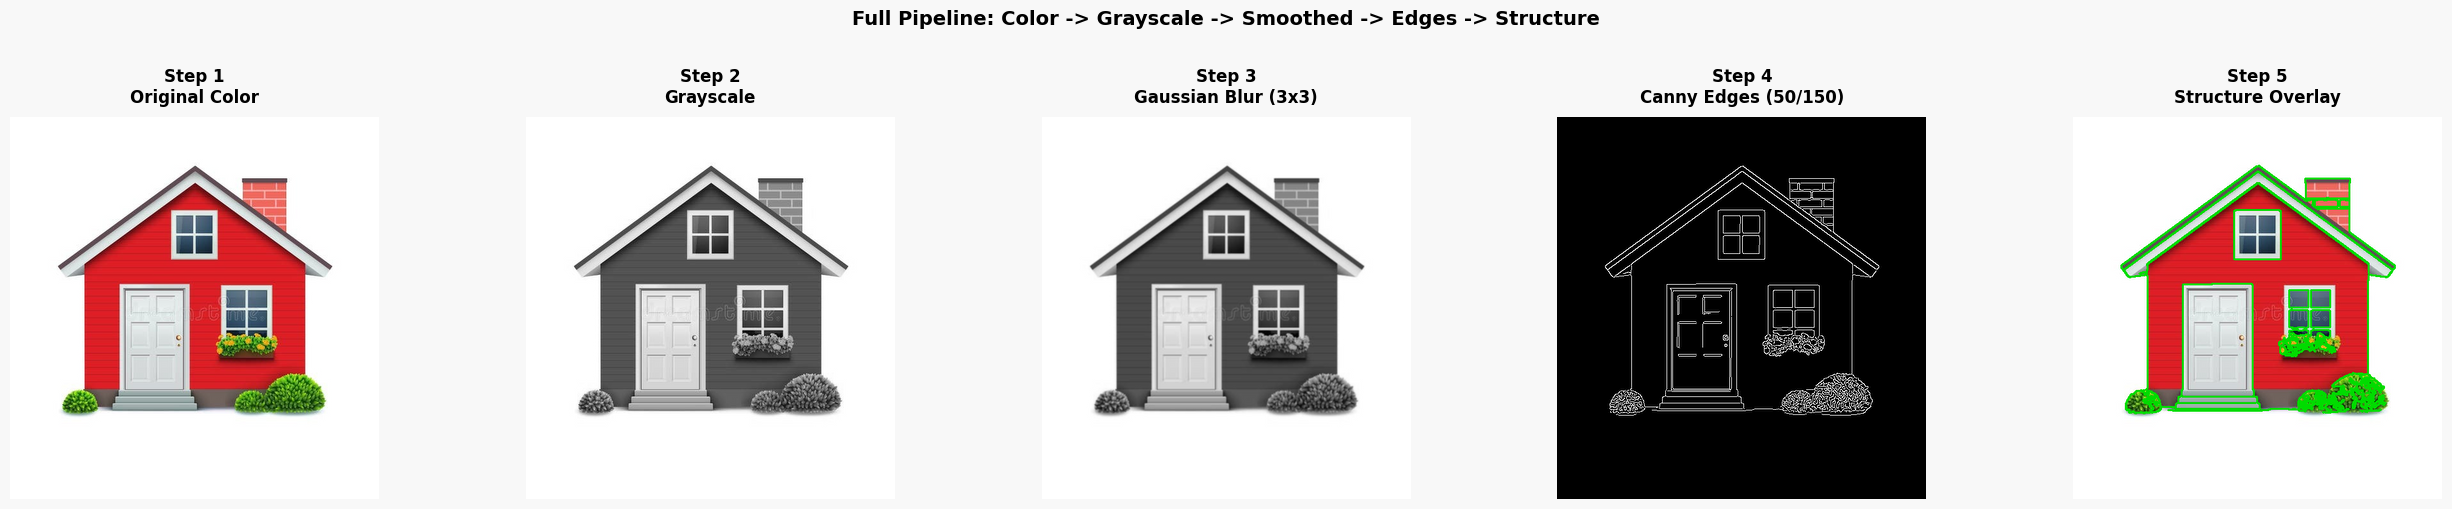

  Saved -> outputs/full_pipeline.jpg


In [18]:
fig, axes = plt.subplots(1, 5, figsize=(26, 5))
fig.suptitle('Full Pipeline: Color -> Grayscale -> Smoothed -> Edges -> Structure',
             fontsize=14, fontweight='bold', y=1.02)

steps = [
    (img_rgb,      'Step 1\nOriginal Color',      None),
    (img_gray,     'Step 2\nGrayscale',            'gray'),
    (img_blur,     'Step 3\nGaussian Blur (3x3)',  'gray'),
    (canny_strict, 'Step 4\nCanny Edges (50/150)', 'gray'),
    (overlay_rgb,  'Step 5\nStructure Overlay',    None),
]

for ax, (img, title, cmap) in zip(axes, steps):
    ax.imshow(img, cmap=cmap, interpolation='lanczos')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout(pad=1.5)
plt.savefig('outputs/full_pipeline.jpg', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved -> outputs/full_pipeline.jpg")

---

## Summary

Here's a recap of the full pipeline — what each step does, how the data changes, and what trade-off is made:

| Step | Operation | Shape Change | Key Trade-off |
|---|---|---|---|
| 1 | Load color image | -> `(H, W, 3)` | Full info, complex representation |
| 2 | Grayscale | `(H, W, 3)` -> `(H, W)` | Lose color, keep brightness and structure |
| 3 | Gaussian blur | `(H, W)` -> `(H, W)` | Lose fine noise, keep major features |
| 4 | Edge detection | `(H, W)` -> `(H, W)` | Lose interior fill, keep boundaries |
| 5 | Contours | edges -> geometry | Lose pixel detail, gain structured shapes |

The pipeline transforms a rich photograph into a sparse but geometrically meaningful description.  
Each step makes a deliberate trade-off — and understanding *what* is lost and *why* it's acceptable is the core insight of this assignment.

---
*Notebook by Joud Thaher*